In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [21]:
df = pd.read_csv('/content/archive (12).zip')

In [22]:
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [23]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [25]:
df.shape

(344, 7)

In [26]:
df.value_counts('species')

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [27]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [28]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [29]:

missing_col=['culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g']
for col in missing_col:
  df[col]=df[col].fillna(df[col].median())

In [30]:
df['sex']=df['sex'].fillna(df['sex'].mode()[0])

In [31]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


<Axes: >

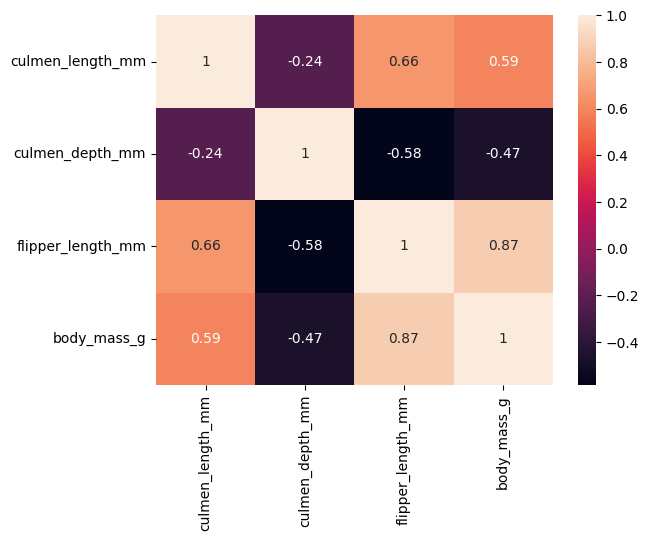

In [32]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [33]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['encode']=le.fit_transform(df['species'])
df['sex_encoded'] =le.fit_transform(df['sex'])
df['island_encoded']=le.fit_transform(df['island'])

In [34]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'encode', 'sex_encoded',
       'island_encoded'],
      dtype='object')

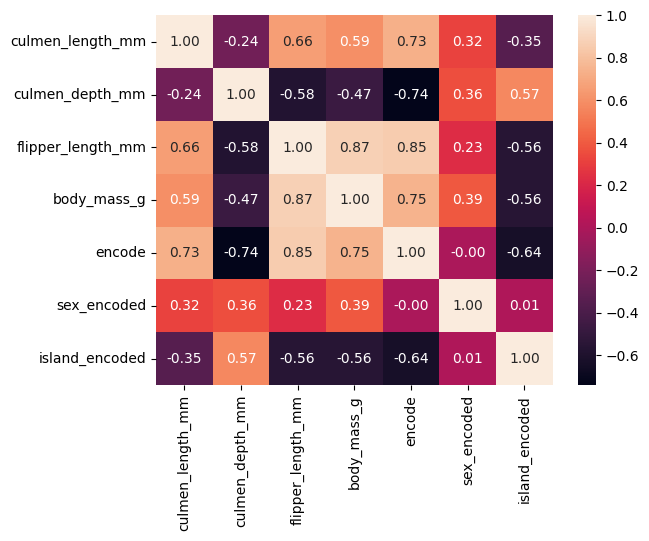

In [35]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt='.2f')
plt.show()

In [36]:
x=df.drop(columns=['species','encode','sex_encoded','sex','island'],axis=1)
y=df['encode']

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=35,stratify=y)

In [38]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 275 entries, 286 to 268
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   275 non-null    float64
 1   culmen_depth_mm    275 non-null    float64
 2   flipper_length_mm  275 non-null    float64
 3   body_mass_g        275 non-null    float64
 4   island_encoded     275 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 12.9 KB


In [39]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled =ss.transform(x_test)

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score

In [41]:
model = Sequential([Dense(32,activation='relu'),Dense(16,activation='relu'),Dense(3,activation='softmax')])

In [42]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [43]:
history = model.fit(x_train_scaled,y_train,epochs=30,batch_size=8,validation_split=0.2)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5273 - loss: 0.9931 - val_accuracy: 0.6909 - val_loss: 0.9137
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8000 - loss: 0.7384 - val_accuracy: 0.8364 - val_loss: 0.6891
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9000 - loss: 0.5255 - val_accuracy: 0.9273 - val_loss: 0.4994
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9545 - loss: 0.3597 - val_accuracy: 0.9455 - val_loss: 0.3644
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9636 - loss: 0.2522 - val_accuracy: 0.9455 - val_loss: 0.2776
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9727 - loss: 0.1844 - val_accuracy: 0.9455 - val_loss: 0.2171
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9818 - loss: 0.1384 - val_accuracy: 0.9455 - val_loss: 0.1701
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9864 - loss: 0.1074 - val_accuracy: 0.9455 - val_loss

In [45]:
loss, acc = model.evaluate(x_test_scaled, y_test, verbose=1)
print(acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 0.0093
1.0


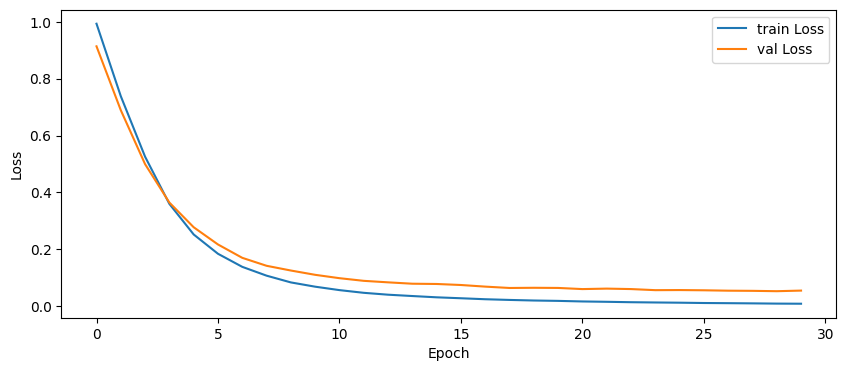

In [46]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label="train Loss")
plt.plot(history.history['val_loss'], label="val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()